In [1]:
import torch 
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from matplotlib import gridspec
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

from mlp import NN

Loading model.

In [2]:
num_classes = 2
size_layers2 = [2, 32, num_classes]
size_layers3 = [3, 32, num_classes]
size_layers5 = [5, 32, num_classes]
size_layers10 = [10, 32, num_classes]
dropout_layers = [0, 0, 0, 0]

mlp2_ausio2 = NN(size_layers2, dropout_layers, nn.ReLU(), device='cpu')
mlp3_ausio2 = NN(size_layers3, dropout_layers, nn.ReLU(), device='cpu')
mlp5_ausio2 = NN(size_layers5, dropout_layers, nn.ReLU(), device='cpu')
mlp10_ausio2 = NN(size_layers10, dropout_layers, nn.ReLU(), device='cpu')
mlp2_all = NN(size_layers2, dropout_layers, nn.ReLU(), device='cpu')
mlp3_all = NN(size_layers3, dropout_layers, nn.ReLU(), device='cpu')
mlp5_all = NN(size_layers5, dropout_layers, nn.ReLU(), device='cpu')
mlp10_all = NN(size_layers10, dropout_layers, nn.ReLU(), device='cpu')

In [3]:
model2_ausio2 = torch.load('best_models/mlp_ld2_ausio2.pth', map_location=torch.device('cpu'), weights_only=True)
model3_ausio2 = torch.load('best_models/mlp_ld3_ausio2.pth', map_location=torch.device('cpu'), weights_only=True)
model5_ausio2 = torch.load('best_models/mlp_ld5_ausio2.pth', map_location=torch.device('cpu'), weights_only=True)
model10_ausio2 = torch.load('best_models/mlp_ld10_ausio2.pth', map_location=torch.device('cpu'), weights_only=True)
model2_all = torch.load('best_models/mlp_ld2_all.pth', map_location=torch.device('cpu'), weights_only=True)
model3_all = torch.load('best_models/mlp_ld3_all.pth', map_location=torch.device('cpu'), weights_only=True)
model5_all = torch.load('best_models/mlp_ld5_all.pth', map_location=torch.device('cpu'), weights_only=True)
model10_all = torch.load('best_models/mlp_ld10_all.pth', map_location=torch.device('cpu'), weights_only=True)

mlp2_ausio2.load_state_dict(model2_ausio2)
mlp3_ausio2.load_state_dict(model3_ausio2)
mlp5_ausio2.load_state_dict(model5_ausio2)
mlp10_ausio2.load_state_dict(model10_ausio2)
mlp2_all.load_state_dict(model2_all)
mlp3_all.load_state_dict(model3_all)
mlp5_all.load_state_dict(model5_all)
mlp10_all.load_state_dict(model10_all)

<All keys matched successfully>

## Learning Curves

Plotting learning curves.

In [4]:
loss_train2 = np.load('best_models/loss_train_mlp_ld2_ausio2.npy')
loss_test2 = np.load('best_models/loss_test_mlp_ld2_ausio2.npy')
loss_train3 = np.load('best_models/loss_train_mlp_ld3_ausio2.npy')
loss_test3 = np.load('best_models/loss_test_mlp_ld3_ausio2.npy')
loss_train5 = np.load('best_models/loss_train_mlp_ld5_ausio2.npy')
loss_test5 = np.load('best_models/loss_test_mlp_ld5_ausio2.npy')
loss_train10 = np.load('best_models/loss_train_mlp_ld10_ausio2.npy')
loss_test10 = np.load('best_models/loss_test_mlp_ld10_ausio2.npy')

epochs2 = [i for i in range(loss_train2.shape[0])]
epochs3 = [i for i in range(loss_train3.shape[0])]
epochs5 = [i for i in range(loss_train5.shape[0])]
epochs10 = [i for i in range(loss_train10.shape[0])]

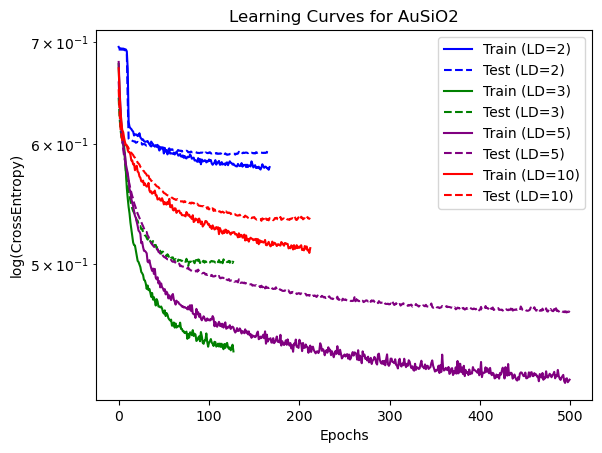

In [5]:
plt.plot(epochs2, loss_train2, label='Train (LD=2)', c='blue')
plt.plot(epochs2, loss_test2, label='Test (LD=2)', c='blue', linestyle='--')
plt.plot(epochs3, loss_train3, label='Train (LD=3)', c='green')
plt.plot(epochs3, loss_test3, label='Test (LD=3)', c='green', linestyle='--')
plt.plot(epochs5, loss_train5, label='Train (LD=5)', c='purple')
plt.plot(epochs5, loss_test5, label='Test (LD=5)', c='purple', linestyle='--')
plt.plot(epochs10, loss_train10, label='Train (LD=10)', c='red')
plt.plot(epochs10, loss_test10, label='Test (LD=10)', c='red', linestyle='--')

plt.yscale('log')
plt.ylabel('log(CrossEntropy)')
plt.xlabel('Epochs')
plt.title('Learning Curves for AuSiO2')
plt.legend()
plt.show()

In [6]:
loss_train2 = np.load('best_models/loss_train_mlp_ld2_all.npy')
loss_test2 = np.load('best_models/loss_test_mlp_ld2_all.npy')
loss_train3 = np.load('best_models/loss_train_mlp_ld3_all.npy')
loss_test3 = np.load('best_models/loss_test_mlp_ld3_all.npy')
loss_train5 = np.load('best_models/loss_train_mlp_ld5_all.npy')
loss_test5 = np.load('best_models/loss_test_mlp_ld5_all.npy')
loss_train10 = np.load('best_models/loss_train_mlp_ld10_all.npy')
loss_test10 = np.load('best_models/loss_test_mlp_ld10_all.npy')

epochs2 = [i for i in range(loss_train2.shape[0])]
epochs3 = [i for i in range(loss_train3.shape[0])]
epochs5 = [i for i in range(loss_train5.shape[0])]
epochs10 = [i for i in range(loss_train10.shape[0])]

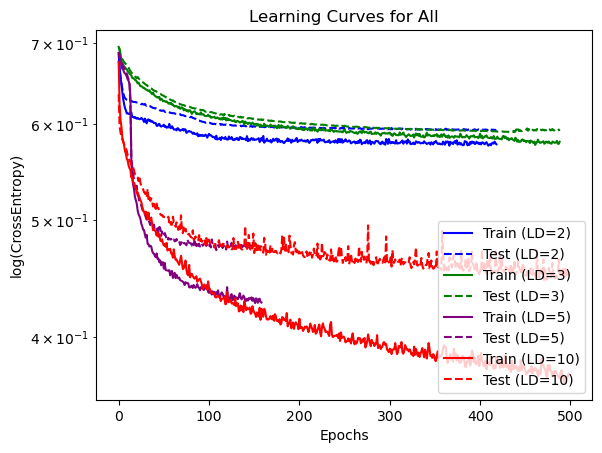

In [7]:
plt.plot(epochs2, loss_train2, label='Train (LD=2)', c='blue')
plt.plot(epochs2, loss_test2, label='Test (LD=2)', c='blue', linestyle='--')
plt.plot(epochs3, loss_train3, label='Train (LD=3)', c='green')
plt.plot(epochs3, loss_test3, label='Test (LD=3)', c='green', linestyle='--')
plt.plot(epochs5, loss_train5, label='Train (LD=5)', c='purple')
plt.plot(epochs5, loss_test5, label='Test (LD=5)', c='purple', linestyle='--')
plt.plot(epochs10, loss_train10, label='Train (LD=10)', c='red')
plt.plot(epochs10, loss_test10, label='Test (LD=10)', c='red', linestyle='--')

plt.yscale('log')
plt.ylabel('log(CrossEntropy)')
plt.xlabel('Epochs')
plt.title('Learning Curves for All')
plt.legend()
plt.show()

## Model avaliation - AuSiO2

Loading data for latent space equal to 2.

In [8]:
data_ausio2_ld2 = torch.tensor(np.load(f"../../best_models/ld2_ausio2_ausio2.npy"), dtype=torch.float32)
labels = torch.tensor(np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels'], dtype=torch.long).squeeze()

x_train, x_test, y_train, y_test = train_test_split(
    data_ausio2_ld2.numpy(), labels.numpy(), 
    test_size=0.2, 
    random_state=42,
    stratify=labels.numpy()
)
train_dataset = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))

batch_size = 32
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

mlp2_ausio2.eval()  

all_preds_ld2 = []
all_labels_ld2 = []

with torch.no_grad():  
    for inputs, labels in test_loader:
        outputs = mlp2_ausio2(inputs)  
        _, preds = torch.max(outputs, 1)  
        all_preds_ld2.append(preds)
        all_labels_ld2.append(labels)

y_pred_ld2 = torch.cat(all_preds_ld2)
y_test_ld2 = torch.cat(all_labels_ld2)

Plotting the confusion matrix.

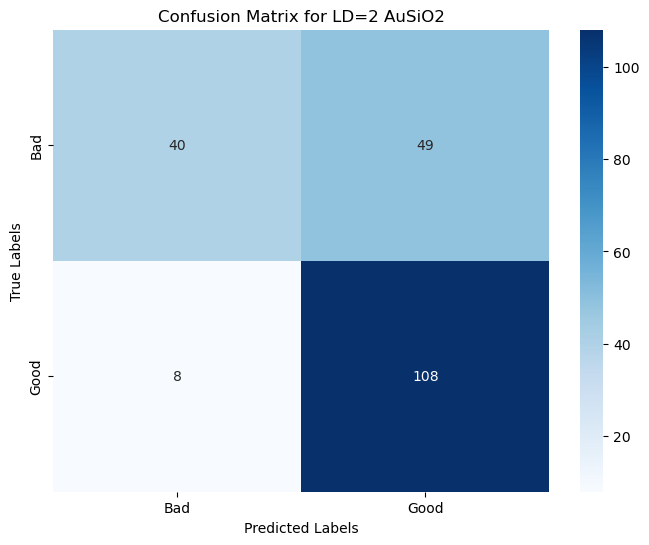

In [9]:
y_pred = y_pred_ld2.numpy()
y_true = y_test_ld2.numpy()

cm = confusion_matrix(y_true, y_pred)
class_names = ['Bad', 'Good']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for LD=2 AuSiO2')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Doing the same for other latent spaces.

In [10]:
data_ausio2_ld3 = torch.tensor(np.load(f"../../best_models/ld3_ausio2_ausio2.npy"), dtype=torch.float32)
labels = torch.tensor(np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels'], dtype=torch.long).squeeze()

x_train, x_test, y_train, y_test = train_test_split(
    data_ausio2_ld3.numpy(), labels.numpy(), 
    test_size=0.2, 
    random_state=42,
    stratify=labels.numpy()
)
train_dataset = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))

batch_size = 32
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

mlp3_ausio2.eval()  

all_preds_ld3 = []
all_labels_ld3 = []

with torch.no_grad():  
    for inputs, labels in test_loader:
        outputs = mlp3_ausio2(inputs)  
        _, preds = torch.max(outputs, 1)  
        all_preds_ld3.append(preds)
        all_labels_ld3.append(labels)

y_pred_ld3 = torch.cat(all_preds_ld3)
y_test_ld3 = torch.cat(all_labels_ld3)

Plotting the confusion matrix:

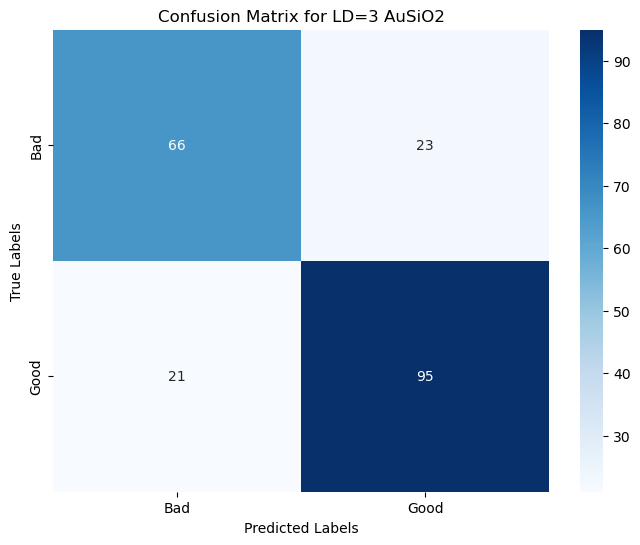

In [11]:
y_pred = y_pred_ld3.numpy()
y_true = y_test_ld3.numpy()

cm = confusion_matrix(y_true, y_pred)
class_names = ['Bad', 'Good']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for LD=3 AuSiO2')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [12]:
data_ausio2_ld5 = torch.tensor(np.load(f"../../best_models/ld5_ausio2_ausio2.npy"), dtype=torch.float32)
labels = torch.tensor(np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels'], dtype=torch.long).squeeze()

x_train, x_test, y_train, y_test = train_test_split(
    data_ausio2_ld5.numpy(), labels.numpy(), 
    test_size=0.2, 
    random_state=42,
    stratify=labels.numpy()
)
train_dataset = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))

batch_size = 32
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

mlp5_ausio2.eval()  

all_preds_ld5 = []
all_labels_ld5 = []

with torch.no_grad():  
    for inputs, labels in test_loader:
        outputs = mlp5_ausio2(inputs)  
        _, preds = torch.max(outputs, 1)  
        all_preds_ld5.append(preds)
        all_labels_ld5.append(labels)

y_pred_ld5 = torch.cat(all_preds_ld5)
y_test_ld5 = torch.cat(all_labels_ld5)

Plotting the confusion matrix.

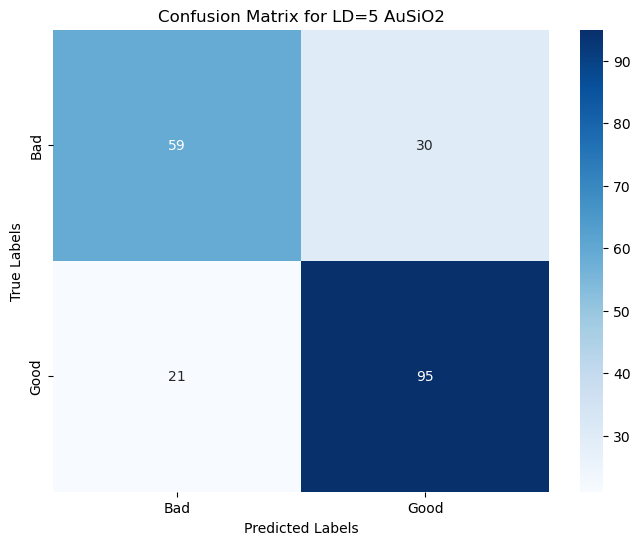

In [13]:
y_pred = y_pred_ld5.numpy()
y_true = y_test_ld5.numpy()

cm = confusion_matrix(y_true, y_pred)
class_names = ['Bad', 'Good']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for LD=5 AuSiO2')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [14]:
data_ausio2_ld10 = torch.tensor(np.load(f"../../best_models/ld10_ausio2_ausio2.npy"), dtype=torch.float32)
labels = torch.tensor(np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels'], dtype=torch.long).squeeze()

x_train, x_test, y_train, y_test = train_test_split(
    data_ausio2_ld10.numpy(), labels.numpy(), 
    test_size=0.2, 
    random_state=42,
    stratify=labels.numpy()
)
train_dataset = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))

batch_size = 32
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

mlp10_ausio2.eval()  

all_preds_ld10 = []
all_labels_ld10 = []

with torch.no_grad():  
    for inputs, labels in test_loader:
        outputs = mlp10_ausio2(inputs)  
        _, preds = torch.max(outputs, 1)  
        all_preds_ld10.append(preds)
        all_labels_ld10.append(labels)

y_pred_ld10 = torch.cat(all_preds_ld10)
y_test_ld10 = torch.cat(all_labels_ld10)

Plotting the confusion matrix.

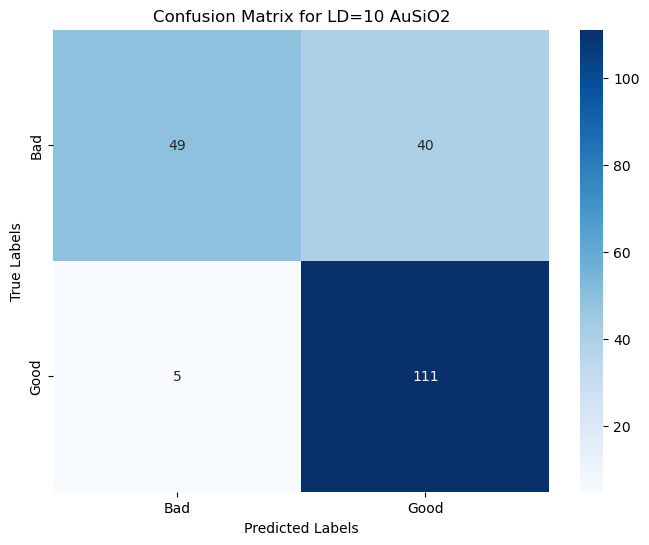

In [15]:
y_pred = y_pred_ld10.numpy()
y_true = y_test_ld10.numpy()

cm = confusion_matrix(y_true, y_pred)
class_names = ['Bad', 'Good']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for LD=10 AuSiO2')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## Model avaliation - All

Loading data for latent space equal to 2.

In [16]:
data_all_ld2 = torch.tensor(np.load(f"../../best_models/ld2_ausio2_all.npy"), dtype=torch.float32)
labels = torch.tensor(np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels'], dtype=torch.long).squeeze()

x_train, x_test, y_train, y_test = train_test_split(
    data_all_ld2.numpy(), labels.numpy(), 
    test_size=0.2, 
    random_state=42,
    stratify=labels.numpy()
)
train_dataset = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))

batch_size = 32
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

mlp2_all.eval()  

all_preds_ld2 = []
all_labels_ld2 = []

with torch.no_grad():  
    for inputs, labels in test_loader:
        outputs = mlp2_all(inputs)  
        _, preds = torch.max(outputs, 1)  
        all_preds_ld2.append(preds)
        all_labels_ld2.append(labels)

y_pred_ld2 = torch.cat(all_preds_ld2)
y_test_ld2 = torch.cat(all_labels_ld2)

Plotting the confusion matrix.

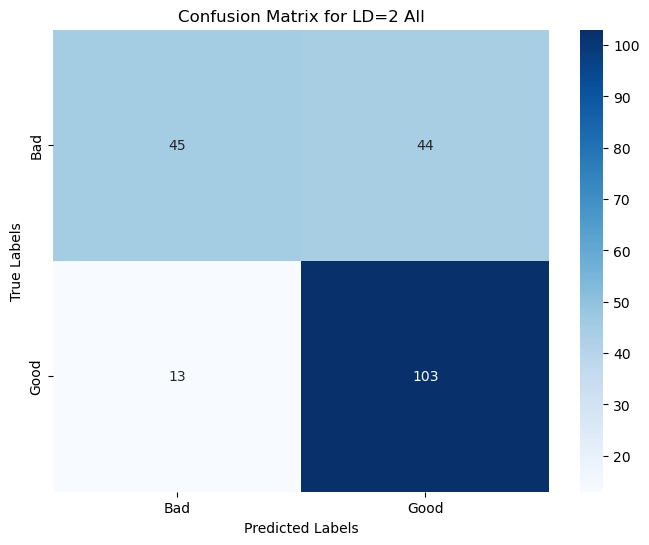

In [17]:
y_pred = y_pred_ld2.numpy()
y_true = y_test_ld2.numpy()

cm = confusion_matrix(y_true, y_pred)
class_names = ['Bad', 'Good']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for LD=2 All')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Doing the same for other latent spaces.

In [18]:
data_all_ld3 = torch.tensor(np.load(f"../../best_models/ld3_ausio2_all.npy"), dtype=torch.float32)
labels = torch.tensor(np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels'], dtype=torch.long).squeeze()

x_train, x_test, y_train, y_test = train_test_split(
    data_all_ld3.numpy(), labels.numpy(), 
    test_size=0.2, 
    random_state=42,
    stratify=labels.numpy()
)
train_dataset = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))

batch_size = 32
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

mlp3_all.eval()  

all_preds_ld3 = []
all_labels_ld3 = []

with torch.no_grad():  
    for inputs, labels in test_loader:
        outputs = mlp3_all(inputs)  
        _, preds = torch.max(outputs, 1)  
        all_preds_ld3.append(preds)
        all_labels_ld3.append(labels)

y_pred_ld3 = torch.cat(all_preds_ld3)
y_test_ld3 = torch.cat(all_labels_ld3)

Plotting the confusion matrix:

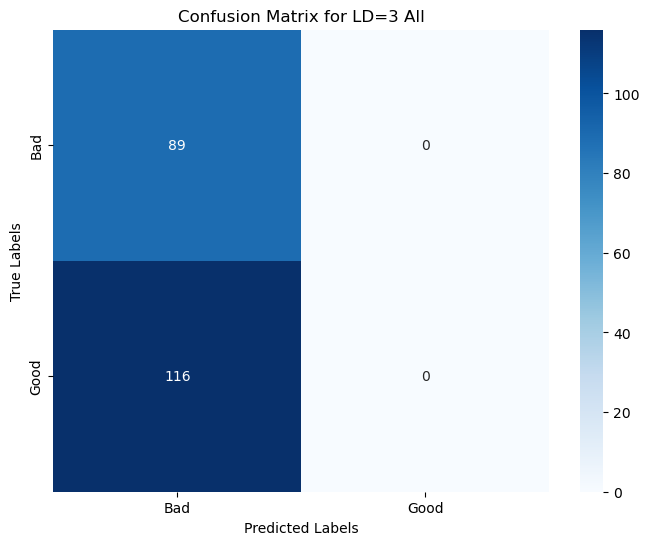

In [19]:
y_pred = y_pred_ld3.numpy()
y_true = y_test_ld3.numpy()

cm = confusion_matrix(y_true, y_pred)
class_names = ['Bad', 'Good']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for LD=3 All')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [20]:
data_all_ld5 = torch.tensor(np.load(f"../../best_models/ld5_ausio2_all.npy"), dtype=torch.float32)
labels = torch.tensor(np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels'], dtype=torch.long).squeeze()

x_train, x_test, y_train, y_test = train_test_split(
    data_all_ld5.numpy(), labels.numpy(), 
    test_size=0.2, 
    random_state=42,
    stratify=labels.numpy()
)
train_dataset = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))

batch_size = 32
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

mlp5_all.eval()  

all_preds_ld5 = []
all_labels_ld5 = []

with torch.no_grad():  
    for inputs, labels in test_loader:
        outputs = mlp5_all(inputs)  
        _, preds = torch.max(outputs, 1)  
        all_preds_ld5.append(preds)
        all_labels_ld5.append(labels)

y_pred_ld5 = torch.cat(all_preds_ld5)
y_test_ld5 = torch.cat(all_labels_ld5)

Plotting the confusion matrix.

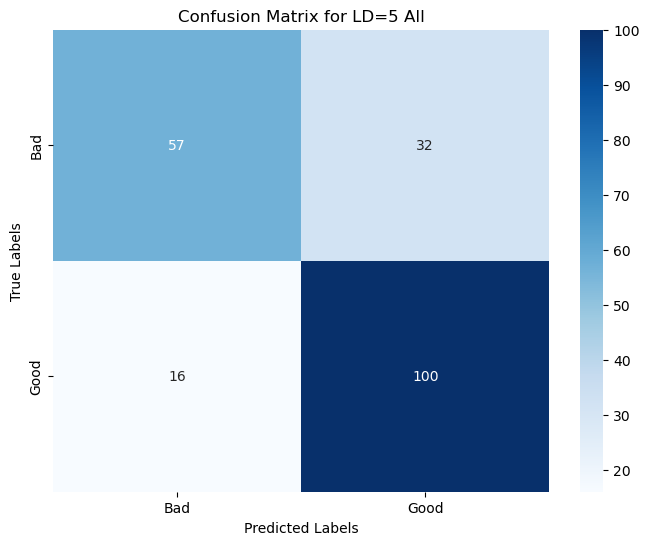

In [21]:
y_pred = y_pred_ld5.numpy()
y_true = y_test_ld5.numpy()

cm = confusion_matrix(y_true, y_pred)
class_names = ['Bad', 'Good']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for LD=5 All')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [22]:
data_all_ld10 = torch.tensor(np.load(f"../../best_models/ld10_ausio2_all.npy"), dtype=torch.float32)
labels = torch.tensor(np.load('../../dataset_TipAu_SiO2_annotated.npz')['labels'], dtype=torch.long).squeeze()

x_train, x_test, y_train, y_test = train_test_split(
    data_all_ld10.numpy(), labels.numpy(), 
    test_size=0.2, 
    random_state=42,
    stratify=labels.numpy()
)
train_dataset = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))

batch_size = 32
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

mlp10_all.eval()  

all_preds_ld10 = []
all_labels_ld10 = []

with torch.no_grad():  
    for inputs, labels in test_loader:
        outputs = mlp10_all(inputs)  
        _, preds = torch.max(outputs, 1)  
        all_preds_ld10.append(preds)
        all_labels_ld10.append(labels)

y_pred_ld10 = torch.cat(all_preds_ld10)
y_test_ld10 = torch.cat(all_labels_ld10)

Plotting the confusion matrix.

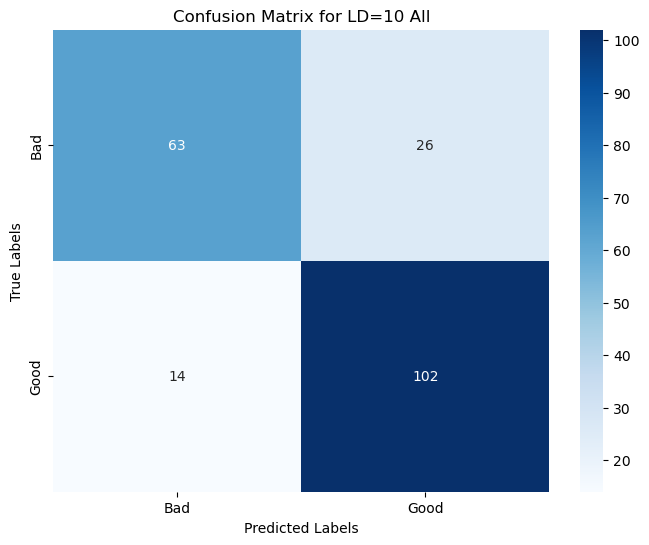

In [23]:
y_pred = y_pred_ld10.numpy()
y_true = y_test_ld10.numpy()

cm = confusion_matrix(y_true, y_pred)
class_names = ['Bad', 'Good']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for LD=10 All')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()